<a href="https://colab.research.google.com/github/IT22091352/ML-Group_Assignment-2026/blob/main/XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# CELL 1: SETUP AND IMPORTS
# ==========================================
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

# Mount Google Drive to access the datasets
print("Mounting Google Drive...")
drive.mount('/content/drive')
print("Google Drive mounted successfully!")

Mounting Google Drive...
Mounted at /content/drive
Google Drive mounted successfully!


In [2]:
import pandas as pd

# ==========================================
# CELL 2: LOAD TRAIN, VALIDATION, AND TEST DATA
# ==========================================
print("=== Loading Datasets from Google Drive ===")

# Update these paths if your folder structure in Drive is different
base_path = '/content/drive/MyDrive/ML-Assignment/CICIoT23/'

train_path = base_path + '/train.csv'
val_path = base_path + '/validation.csv'
test_path = base_path + '/test.csv'

print("Loading Data (Taking advantage of Colab RAM)...")
# Loading 1 Million rows for training to get better accuracy
df_train = pd.read_csv(train_path, nrows=1000000)
df_val = pd.read_csv(val_path, nrows=200000)
df_test = pd.read_csv(test_path, nrows=300000)

print(f"Train shape: {df_train.shape}")
print(f"Validation shape: {df_val.shape}")
print(f"Test shape: {df_test.shape}\n")

=== Loading Datasets from Google Drive ===
Loading Data (Taking advantage of Colab RAM)...
Train shape: (1000000, 47)
Validation shape: (200000, 47)
Test shape: (300000, 47)



In [8]:
# ==========================================
# DATASET PREVIEW (BEFORE PREPROCESSING)
# ==========================================
print("=== Dataset Preview (Training Data) ===\n")

# 1. තීරු වල නම් සියල්ල බලාගැනීම (View all column names)
print("1. Column Names (Total: {} columns):".format(len(df_train.columns)))
print(list(df_train.columns))
print("-" * 50)

# 2. Data Types සහ හිස් තැන් (Null values) ගැන සාරාංශයක් බලාගැනීම
print("\n2. Dataset Information (Data Types & Non-Null Counts):")
df_train.info()
print("-" * 50)

# 3. Dataset එකේ මුල් පේළි 5 වගුවක් විදියට බලාගැනීම (Preview first 5 rows)
print("\n3. First 5 Rows of the Dataset:")
display(df_train.head())

=== Dataset Preview (Training Data) ===

1. Column Names (Total: 47 columns):
['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']
--------------------------------------------------

2. Dataset Information (Data Types & Non-Null Counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 47 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   flow_duration    1000000 non-null  float64
 1   Header_Length    1000000

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,757.00,6.00,64.00,23.671858,23.671858,0.0,0.0,0.0,0.0,...,538.470740,944.00,8.334058e+07,9.5,41.845546,761.456760,305219.322301,0.95,141.55,DDoS-ACK_Fragmentation
1,0.000000,54.00,6.00,64.00,2.393046,2.393046,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.309327e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
2,0.033982,56.78,6.11,64.64,1.192715,1.192715,0.0,0.0,0.0,0.0,...,1.727526,54.29,8.333086e+07,9.5,10.462813,2.445286,16.853118,0.19,141.55,DDoS-PSHACK_Flood
3,0.000000,0.00,47.00,64.00,9.841972,9.841972,0.0,0.0,0.0,0.0,...,0.000000,592.00,8.370278e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
4,3.944828,108.00,6.00,64.00,0.506993,0.506993,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.297270e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood


In [3]:
# ==========================================
# CELL 3: DATA CLEANING & LABEL ENCODING
# ==========================================
print("=== Data Cleaning & Feature Separation ===")

# 1. Handle Infinity and Missing Values
for df, name in zip([df_train, df_val, df_test], ['Train', 'Validation', 'Test']):
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    print(f"Cleaned {name} shape: {df.shape}")

# 2. Separate Features and Targets
X_train, y_train = df_train.drop('label', axis=1), df_train['label']
X_val, y_val = df_val.drop('label', axis=1), df_val['label']
X_test, y_test = df_test.drop('label', axis=1), df_test['label']

# 3. Label Encoding
print("\nEncoding target labels into numeric values...")
label_encoder = LabelEncoder()
label_encoder.fit(pd.concat([y_train, y_val, y_test]))

y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)
print("Encoding complete!")

=== Data Cleaning & Feature Separation ===
Cleaned Train shape: (1000000, 47)
Cleaned Validation shape: (200000, 47)
Cleaned Test shape: (300000, 47)

Encoding target labels into numeric values...
Encoding complete!


In [4]:
# ==========================================
# CELL 4: FEATURE SCALING
# ==========================================
print("=== Consistent Feature Scaling ===")

scaler = StandardScaler()

print("Fitting scaler on Training data and transforming all sets to prevent data leakage...")
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete! Data is ready for the model.")

=== Consistent Feature Scaling ===
Fitting scaler on Training data and transforming all sets to prevent data leakage...
Scaling complete! Data is ready for the model.


In [5]:
# ==========================================
# CELL 5: XGBOOST TRAINING WITH GPU & EARLY STOPPING
# ==========================================
print("=== Training XGBoost with GPU Acceleration ===")

# Using GPU for ultra-fast training on 1 Million rows
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    tree_method='hist',  # Optimized for large datasets
    device='cuda',       # ENABLE GPU ACCELERATION IN COLAB
    early_stopping_rounds=10
)

print("Training the model (Monitoring Validation Loss)...")
xgb_model.fit(
    X_train_scaled,
    y_train_encoded,
    eval_set=[(X_val_scaled, y_val_encoded)],
    verbose=True # Set to True to see the GPU training speed in real-time
)
print(f"\nTraining stopped at best iteration: {xgb_model.best_iteration}")

=== Training XGBoost with GPU Acceleration ===
Training the model (Monitoring Validation Loss)...
[0]	validation_0-mlogloss:0.97650
[1]	validation_0-mlogloss:0.74302
[2]	validation_0-mlogloss:0.88161
[3]	validation_0-mlogloss:1.20578
[4]	validation_0-mlogloss:1.05565
[5]	validation_0-mlogloss:0.65485
[6]	validation_0-mlogloss:1.02731
[7]	validation_0-mlogloss:0.88398
[8]	validation_0-mlogloss:0.56070
[9]	validation_0-mlogloss:0.59173
[10]	validation_0-mlogloss:0.78979
[11]	validation_0-mlogloss:0.49930
[12]	validation_0-mlogloss:0.46438
[13]	validation_0-mlogloss:0.36102
[14]	validation_0-mlogloss:0.34668
[15]	validation_0-mlogloss:0.33939
[16]	validation_0-mlogloss:0.35395
[17]	validation_0-mlogloss:0.32320
[18]	validation_0-mlogloss:0.30501
[19]	validation_0-mlogloss:0.31892
[20]	validation_0-mlogloss:0.28820
[21]	validation_0-mlogloss:0.33124
[22]	validation_0-mlogloss:0.27711
[23]	validation_0-mlogloss:0.26918
[24]	validation_0-mlogloss:0.25480
[25]	validation_0-mlogloss:0.25085
[2

=== Evaluating on Unseen Test Data ===

             XGBoost GPU Model Results             
Accuracy : 0.9896  (98.96%)
F1-Score : 0.9895  (98.95%)

Classification Report:
                         precision    recall  f1-score   support

       Backdoor_Malware       0.07      0.08      0.07        25
          BenignTraffic       0.89      0.91      0.90      6984
       BrowserHijacking       0.16      0.21      0.18        34
       CommandInjection       0.21      0.19      0.20        31
 DDoS-ACK_Fragmentation       1.00      0.99      1.00      1825
        DDoS-HTTP_Flood       0.95      0.95      0.95       170
        DDoS-ICMP_Flood       1.00      1.00      1.00     46157
DDoS-ICMP_Fragmentation       0.99      1.00      0.99      2942
      DDoS-PSHACK_Flood       1.00      1.00      1.00     26448
       DDoS-RSTFINFlood       1.00      1.00      1.00     25982
         DDoS-SYN_Flood       1.00      1.00      1.00     26011
         DDoS-SlowLoris       0.91      0.93   

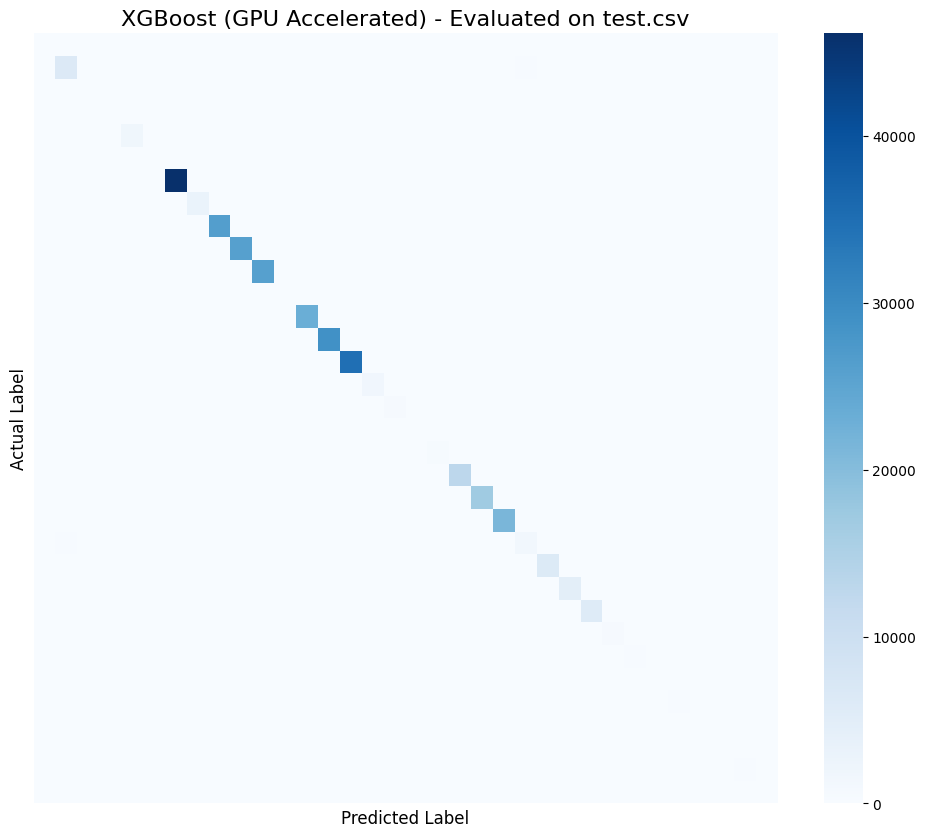


Full ML Pipeline executed successfully on Google Colab!


In [6]:
# ==========================================
# CELL 6: EVALUATION AND VISUALIZATION
# ==========================================
print("=== Evaluating on Unseen Test Data ===")

y_pred = xgb_model.predict(X_test_scaled)

print("\n" + "="*50)
print("             XGBoost GPU Model Results             ")
print("="*50)

accuracy = accuracy_score(y_test_encoded, y_pred)
f1 = f1_score(y_test_encoded, y_pred, average='weighted')

print(f"Accuracy : {accuracy:.4f}  ({(accuracy*100):.2f}%)")
print(f"F1-Score : {f1:.4f}  ({(f1*100):.2f}%)\n")

# Dynamically handle labels present in the test set
present_labels = np.unique(np.concatenate((y_test_encoded, y_pred)))
present_target_names = label_encoder.inverse_transform(present_labels)

warnings.filterwarnings('ignore', category=UserWarning)
print("Classification Report:")
print(classification_report(y_test_encoded, y_pred, labels=present_labels, target_names=present_target_names))

# Confusion Matrix Heatmap
print("\nGenerating Confusion Matrix Plot...")
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=False, yticklabels=False)
plt.title('XGBoost (GPU Accelerated) - Evaluated on test.csv', fontsize=16)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

print("\nFull ML Pipeline executed successfully on Google Colab!")

=== Extracting Feature Importance ===


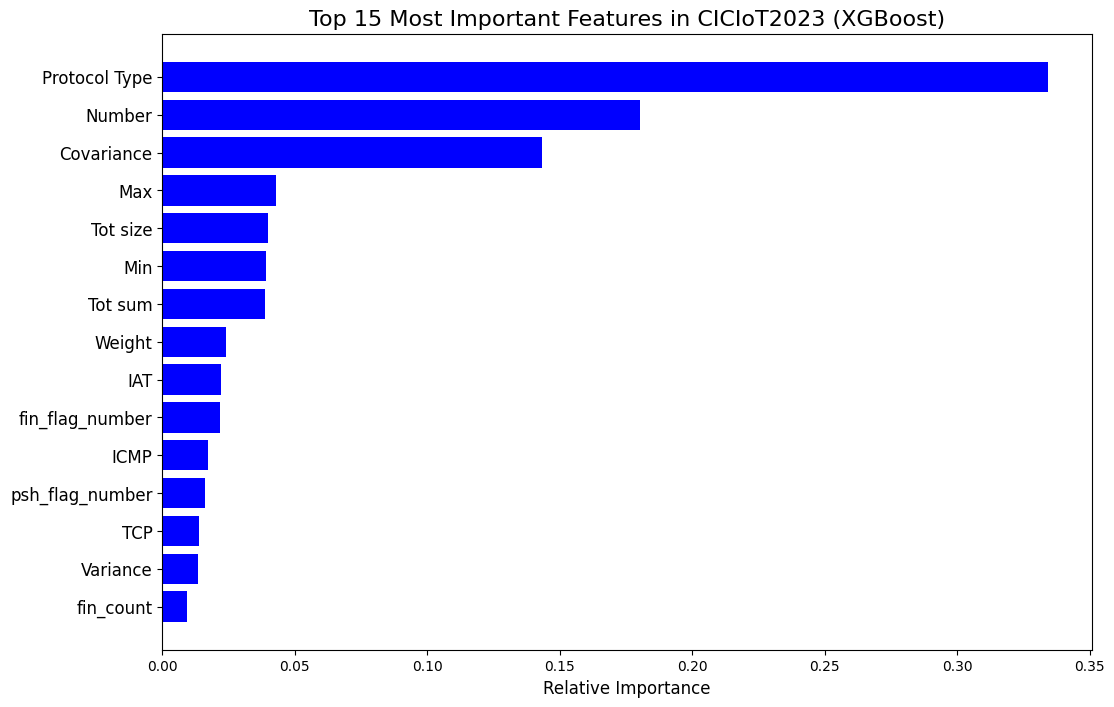

Dimensionality Analysis: These top features contribute the most to the model's decisions.


In [9]:
# ==========================================
# CELL 7: FEATURE IMPORTANCE (RUBRIC REQUIREMENT)
# ==========================================
print("=== Extracting Feature Importance ===")

# Get feature importances from the trained model
importances = xgb_model.feature_importances_
feature_names = X_train.columns

# Sort the feature importances in descending order and get the top 15
indices = np.argsort(importances)[-15:]

plt.figure(figsize=(12, 8))
plt.title('Top 15 Most Important Features in CICIoT2023 (XGBoost)', fontsize=16)
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices], fontsize=12)
plt.xlabel('Relative Importance', fontsize=12)
plt.show()

print("Dimensionality Analysis: These top features contribute the most to the model's decisions.")

In [7]:
# ==========================================
# VIEW LABEL ENCODING MAPPING
# ==========================================
print("=== Target Label Mapping (Number -> Attack Name) ===\n")

# Extract the classes from the fitted LabelEncoder
for index, attack_name in enumerate(label_encoder.classes_):
    print(f"Number {index:2d}  --->  {attack_name}")

=== Target Label Mapping (Number -> Attack Name) ===

Number  0  --->  Backdoor_Malware
Number  1  --->  BenignTraffic
Number  2  --->  BrowserHijacking
Number  3  --->  CommandInjection
Number  4  --->  DDoS-ACK_Fragmentation
Number  5  --->  DDoS-HTTP_Flood
Number  6  --->  DDoS-ICMP_Flood
Number  7  --->  DDoS-ICMP_Fragmentation
Number  8  --->  DDoS-PSHACK_Flood
Number  9  --->  DDoS-RSTFINFlood
Number 10  --->  DDoS-SYN_Flood
Number 11  --->  DDoS-SlowLoris
Number 12  --->  DDoS-SynonymousIP_Flood
Number 13  --->  DDoS-TCP_Flood
Number 14  --->  DDoS-UDP_Flood
Number 15  --->  DDoS-UDP_Fragmentation
Number 16  --->  DNS_Spoofing
Number 17  --->  DictionaryBruteForce
Number 18  --->  DoS-HTTP_Flood
Number 19  --->  DoS-SYN_Flood
Number 20  --->  DoS-TCP_Flood
Number 21  --->  DoS-UDP_Flood
Number 22  --->  MITM-ArpSpoofing
Number 23  --->  Mirai-greeth_flood
Number 24  --->  Mirai-greip_flood
Number 25  --->  Mirai-udpplain
Number 26  --->  Recon-HostDiscovery
Number 27  --->  Reco

In [10]:
# ==========================================
# CELL 7: TEST THE MODEL WITH A SINGLE RECORD (VIVA / VIDEO DEMO)
# ==========================================
import random

print("=== Real-time Intrusion Detection Demo ===\n")

# 1. Test Dataset එකෙන් අහඹු ලෙස එක පේළියක් (Single record) තෝරාගැනීම
random_index = random.randint(0, len(X_test) - 1)
sample_packet = X_test.iloc[[random_index]] # Dataframe පේළියක් ලෙස ලබාගැනීම

# ඇත්තටම ඒක මොන ප්‍රහාරයක්ද කියලා අපි හොයාගන්නවා (හැබැයි Model එකට කියන්නේ නෑ)
actual_label_encoded = y_test_encoded[random_index]
actual_label_text = label_encoder.inverse_transform([actual_label_encoded])[0]

print(f"Selected Packet Index: {random_index}")
print(f"ACTUAL Traffic Type (Hidden from Model): {actual_label_text}\n")

# 2. දත්ත Preprocess කිරීම (Scaling)
# අපි කලින් Train Data වලින් හදාගත්ත Scaler එකම පාවිච්චි කරලා මේ තනි පේළියත් Scale කරනවා
sample_packet_scaled = scaler.transform(sample_packet)

# 3. Model එකෙන් අනුමාන කිරීම (Prediction)
print("Analyzing network packet through XGBoost Model...")
predicted_label_encoded = xgb_model.predict(sample_packet_scaled)

# ඉලක්කමෙන් ආපු උත්තරේ ආපහු වචනයකට (Text) හැරවීම
predicted_label_text = label_encoder.inverse_transform(predicted_label_encoded)[0]

# 4. ප්‍රතිඵලය පෙන්වීම
print("-" * 50)
print(f"🛡️ MODEL PREDICTION: {predicted_label_text}")
print("-" * 50)

# උත්තරේ හරිද වැරදිද කියලා පරීක්ෂා කිරීම
if actual_label_text == predicted_label_text:
    print("\n✅ SUCCESS: The model correctly identified the network traffic!")
else:
    print("\n❌ FAILED: The model misclassified the network traffic.")

=== Real-time Intrusion Detection Demo ===

Selected Packet Index: 6080
ACTUAL Traffic Type (Hidden from Model): DDoS-RSTFINFlood

Analyzing network packet through XGBoost Model...
--------------------------------------------------
🛡️ MODEL PREDICTION: DDoS-RSTFINFlood
--------------------------------------------------

✅ SUCCESS: The model correctly identified the network traffic!


In [13]:
display(df_test.iloc[[550]])

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
550,0.131102,75.6,6.0,64.0,6.130848,6.130848,0.0,0.0,1.0,0.0,...,0.0,54.0,8.336240e+07,9.5,10.392305,0.0,0.0,0.0,141.55,DDoS-SynonymousIP_Flood


In [14]:
# ==========================================
# CELL 7: MANUAL PACKET INSPECTION & VERIFICATION
# ==========================================
print("=== Cross-Checking Model vs Actual Dataset ===\n")

# 1. ඔයාට පරීක්ෂා කරන්න ඕනේ පේළියේ අංකය මෙතන දෙන්න
# (උදාහරණයක් විදියට අපි Test Data එකේ 550 වෙනි පේළිය ගමු)
row_number = 550

# අදාළ පේළියේ දත්ත (Features) සහ උත්තරය (Label) මුල් Dataset එකෙන්ම ලබාගැනීම
my_packet = X_test.iloc[[row_number]]
actual_label = y_test.iloc[row_number] # මේ තියෙන්නේ Dataset එකේ මුලින්ම තිබ්බ වචනයමයි

print("--- 1. Original Dataset එකේ තියෙන ඇත්තම විස්තර ---")
print(f"තෝරාගත් පේළි අංකය (Index): {row_number}")
print(f"Dataset එකේ තියෙන ඇත්තම Attack එක: ** {actual_label} **")

# පේළිය හොයාගන්න ලේසි වෙන්න ඒකේ තියෙන දත්ත (Features) කීපයක් බලාගමු
print(f"මේ Packet එකේ Flow Duration එක: {my_packet['flow_duration'].values[0]}")
print(f"මේ Packet එකේ Header Length එක: {my_packet['Header_Length'].values[0]}\n")


# 2. දැන් අපි මේ පේළියම (උත්තරේ හංගලා) Model එකට දීලා බලමු
print("--- 2. Model එකේ අනුමානය (Prediction) ---")

# දත්ත Scale කිරීම
my_packet_scaled = scaler.transform(my_packet)

# Model එකෙන් අනුමාන කිරීම
predicted_encoded = xgb_model.predict(my_packet_scaled)
predicted_label = label_encoder.inverse_transform(predicted_encoded)[0]

print(f"Model එක අනුමාන කරපු Attack එක: ** {predicted_label} **\n")


# 3. දෙකම සමානද කියලා පරීක්ෂා කිරීම
print("--- 3. අවසන් නිගමනය ---")
if actual_label == predicted_label:
    print(f"✅ SUCCESS: Dataset එකේ තියෙන '{actual_label}' කියන එකමයි Model එකත් කිව්වේ! Model එක 100% නිවැරදියි.")
else:
    print(f"❌ FAILED: Dataset එකේ තියෙන්නේ '{actual_label}' වුණාට, Model එක කිව්වේ '{predicted_label}' කියලා.")

=== Cross-Checking Model vs Actual Dataset ===

--- 1. Original Dataset එකේ තියෙන ඇත්තම විස්තර ---
තෝරාගත් පේළි අංකය (Index): 550
Dataset එකේ තියෙන ඇත්තම Attack එක: ** DDoS-SynonymousIP_Flood **
මේ Packet එකේ Flow Duration එක: 0.1311020565032959
මේ Packet එකේ Header Length එක: 75.6

--- 2. Model එකේ අනුමානය (Prediction) ---
Model එක අනුමාන කරපු Attack එක: ** DDoS-SynonymousIP_Flood **

--- 3. අවසන් නිගමනය ---
✅ SUCCESS: Dataset එකේ තියෙන 'DDoS-SynonymousIP_Flood' කියන එකමයි Model එකත් කිව්වේ! Model එක 100% නිවැරදියි.
